In [2]:
import pandas as pd
df= pd.read_csv("platform_statistics_2026.csv")
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   platform                       17 non-null     object 
 1   monthly_active_users_billions  17 non-null     float64
 2   year_over_year_growth_pct      17 non-null     float64
 3   avg_daily_time_minutes         17 non-null     int64  
 4   primary_age_group              17 non-null     object 
 5   primary_content_format         17 non-null     object 
 6   avg_engagement_rate_pct        17 non-null     float64
 7   social_commerce_adoption_pct   17 non-null     float64
 8   headquarters_country           17 non-null     object 
 9   founded_year                   17 non-null     int64  
 10  data_source                    17 non-null     object 
dtypes: float64(4), int64(2), object(5)
memory usage: 1.6+ KB


,platform,monthly_active_users_billions,year_over_year_growth_pct,avg_daily_time_minutes,primary_age_group,primary_content_format,avg_engagement_rate_pct,social_commerce_adoption_pct,headquarters_country,founded_year,data_source
0,Facebook,3.07,2.5,33,25-34,Mixed/Video,1.5,60.9,USA,2004,Statista/Meta
1,Instagram,3.00,13.0,35,18-34,Reels/Stories,2.2,35.0,USA,2010,Meta/Reuters
2,YouTube,2.58,5.5,48,18-49,Long/Short Video,1.9,22.0,USA,2005,Statista
3,WhatsApp,3.00,4.0,28,25-44,Messaging,0.0,15.0,USA,2009,Meta
4,TikTok,1.99,17.0,58,18-24,Short-Form Video,2.8,43.8,China,2016,Statista


In [3]:
df.isnull().sum() 

platform                         0
monthly_active_users_billions    0
year_over_year_growth_pct        0
avg_daily_time_minutes           0
primary_age_group                0
primary_content_format           0
avg_engagement_rate_pct          0
social_commerce_adoption_pct     0
headquarters_country             0
founded_year                     0
data_source                      0
dtype: int64

In [4]:
df.duplicated().sum() 

np.int64(0)

In [6]:
import pandas as pd
df=pd.read_csv('social_media_user_behavior.csv')
df.info()
df.describe()
df.head()
df.isnull().sum() 
df.duplicated().sum() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             25000 non-null  object 
 1   age                                 25000 non-null  int64  
 2   age_group                           25000 non-null  object 
 3   gender                              25000 non-null  object 
 4   country                             25000 non-null  object 
 5   occupation                          25000 non-null  object 
 6   education_level                     25000 non-null  object 
 7   income_bracket                      25000 non-null  object 
 8   relationship_status                 25000 non-null  object 
 9   primary_platform                    25000 non-null  object 
 10  num_platforms_used                  25000 non-null  int64  
 11  daily_screen_time_minutes           25000

np.int64(0)

In [11]:
import pandas as pd

df = pd.read_csv('social_media_user_behavior.csv')
col = df['daily_screen_time_minutes']

Q1  = col.quantile(0.25)  
Q3  = col.quantile(0.75)   
IQR = Q3 - Q1              

alt_sinir = Q1 - 1.5 * IQR 
ust_sinir = Q3 + 1.5 * IQR

outliers = df[(col < alt_sinir) | (col > ust_sinir)]
print(f"Toplam: {len(outliers)} aykırı değer")

df_clean = df[(col >= alt_sinir) & (col <= ust_sinir)]

Toplam: 154 aykırı değer


In [13]:
import pandas as pd

df = pd.read_csv('social_media_user_behavior.csv')
col = df['followers_count']

Q1  = col.quantile(0.25)  
Q3  = col.quantile(0.75)   
IQR = Q3 - Q1              

alt_sinir = Q1 - 1.5 * IQR 
ust_sinir = Q3 + 1.5 * IQR

outliers = df[(col < alt_sinir) | (col > ust_sinir)]
print(f"Toplam: {len(outliers)} aykırı değer")

df_clean = df[(col >= alt_sinir) & (col <= ust_sinir)]

Toplam: 3271 aykırı değer


In [13]:
import pandas as pd

df = pd.read_csv('social_media_user_behavior.csv')
col = df['monthly_social_spending_usd']

Q1  = col.quantile(0.25)  
Q3  = col.quantile(0.75)   
IQR = Q3 - Q1              

alt_sinir = Q1 - 1.5 * IQR 
ust_sinir = Q3 + 1.5 * IQR

outliers = df[(col < alt_sinir) | (col > ust_sinir)]
print(f"Toplam: {len(outliers)} aykırı değer")

df_clean = df[(col >= alt_sinir) & (col <= ust_sinir)]

Toplam: 1217 aykırı değer


In [17]:
import pandas as pd
df = pd.read_csv('social_media_user_behavior.csv')
col= df['following_count']

Q1  = col.quantile(0.25)  
Q3  = col.quantile(0.75)   
IQR = Q3 - Q1              

alt_sinir = Q1 - 1.5 * IQR 
ust_sinir = Q3 + 1.5 * IQR

outliers = df[(col < alt_sinir) | (col > ust_sinir)]
print(f"Toplam: {len(outliers)} aykırı değer")

df_clean = df[(col >= alt_sinir) & (col <= ust_sinir)]

Toplam: 2673 aykırı değer


In [14]:
import pandas as pd

df = pd.read_csv('social_media_user_behavior.csv')

df['account_created_date'] = pd.to_datetime(
    df['account_created_date']
)

today = pd.Timestamp('today')
df['account_age_years'] = (
    (today - df['account_created_date']).dt.days / 365.25
).round(1)

print(df['account_age_years'].describe())
print(df['account_age_years'].value_counts(bins=5).sort_index())

count    25000.000000
mean         8.204128
std          4.681433
min          0.100000
25%          4.200000
50%          8.200000
75%         12.300000
max         16.300000
Name: account_age_years, dtype: float64
(0.0828, 3.34]    5023
(3.34, 6.58]      4868
(6.58, 9.82]      5098
(9.82, 13.06]     4972
(13.06, 16.3]     5039
Name: count, dtype: int64


In [7]:
cat_cols = ['primary_platform', 'gender', 'primary_device',
            'preferred_content_type', 'usage_purpose']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())

--- primary_platform ---
primary_platform
Instagram      4434
Facebook       3939
YouTube        3759
TikTok         3594
X (Twitter)    1544
Snapchat       1267
LinkedIn       1209
Pinterest      1021
Reddit         1016
WhatsApp        791
Telegram        718
Threads         534
Bluesky         478
Rednote         466
Discord         230
Name: count, dtype: int64
--- gender ---
gender
Female               11930
Male                 11574
Non-Binary            1009
Prefer Not to Say      487
Name: count, dtype: int64
--- primary_device ---
primary_device
Smartphone    15573
Desktop        4421
Tablet         2510
Smart TV       1789
Wearable        707
Name: count, dtype: int64
--- preferred_content_type ---
preferred_content_type
Short-Form Video    5575
Image/Photo         3752
Story/Reel          3603
Text Post           2489
Long-Form Video     2434
Carousel            1737
Meme                1239
Live Stream         1228
Poll/Quiz           1004
Podcast/Audio        741
Article/

In [12]:
cat_cols = ['primary_platform', 'gender', 'primary_device',
            'preferred_content_type', 'usage_purpose']

for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

In [26]:
df['primary_platform'] = df['primary_platform'].replace({
    'Tiktok'    : 'TikTok',
    'tiktok'    : 'TikTok',
    'TIKTOK'    : 'TikTok',
    'Youtube'   : 'YouTube',
    'Whatsapp'  : 'WhatsApp',
    'Linkedin'  : 'LinkedIn',
})


platform_map = {
    'TikTok': 'TikTok', 'tiktok': 'TikTok',
    'Instagram': 'Instagram',
    'Facebook': 'Facebook', 'FACEBOOK': 'Facebook',
}
df['primary_platform'] = df['primary_platform'].map(platform_map)


In [11]:
import pandas as pd

df = pd.read_csv('social_media_user_behavior.csv')

cat_cols = ['primary_platform', 'gender', 'primary_device',
            'preferred_content_type', 'usage_purpose']

for col in cat_cols:
    df[col] = df[col].str.strip().str.title()


df['primary_platform'] = df['primary_platform'].replace({
    'Tiktok'   : 'TikTok',
    'Youtube'  : 'YouTube',
    'Whatsapp' : 'WhatsApp',
    'Linkedin' : 'LinkedIn',
})

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique değer")
    print(df[col].value_counts().head(5))

primary_platform: 15 unique değer
primary_platform
Instagram      4434
Facebook       3939
YouTube        3759
TikTok         3594
X (Twitter)    1544
Name: count, dtype: int64
gender: 4 unique değer
gender
Female               11930
Male                 11574
Non-Binary            1009
Prefer Not To Say      487
Name: count, dtype: int64
primary_device: 5 unique değer
primary_device
Smartphone    15573
Desktop        4421
Tablet         2510
Smart Tv       1789
Wearable        707
Name: count, dtype: int64
preferred_content_type: 12 unique değer
preferred_content_type
Short-Form Video    5575
Image/Photo         3752
Story/Reel          3603
Text Post           2489
Long-Form Video     2434
Name: count, dtype: int64
usage_purpose: 10 unique değer
usage_purpose
News & Information     2581
Entertainment          2572
Social Networking      2565
Brand Marketing        2528
Shopping/E-Commerce    2487
Name: count, dtype: int64


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('social_media_user_behavior.csv')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

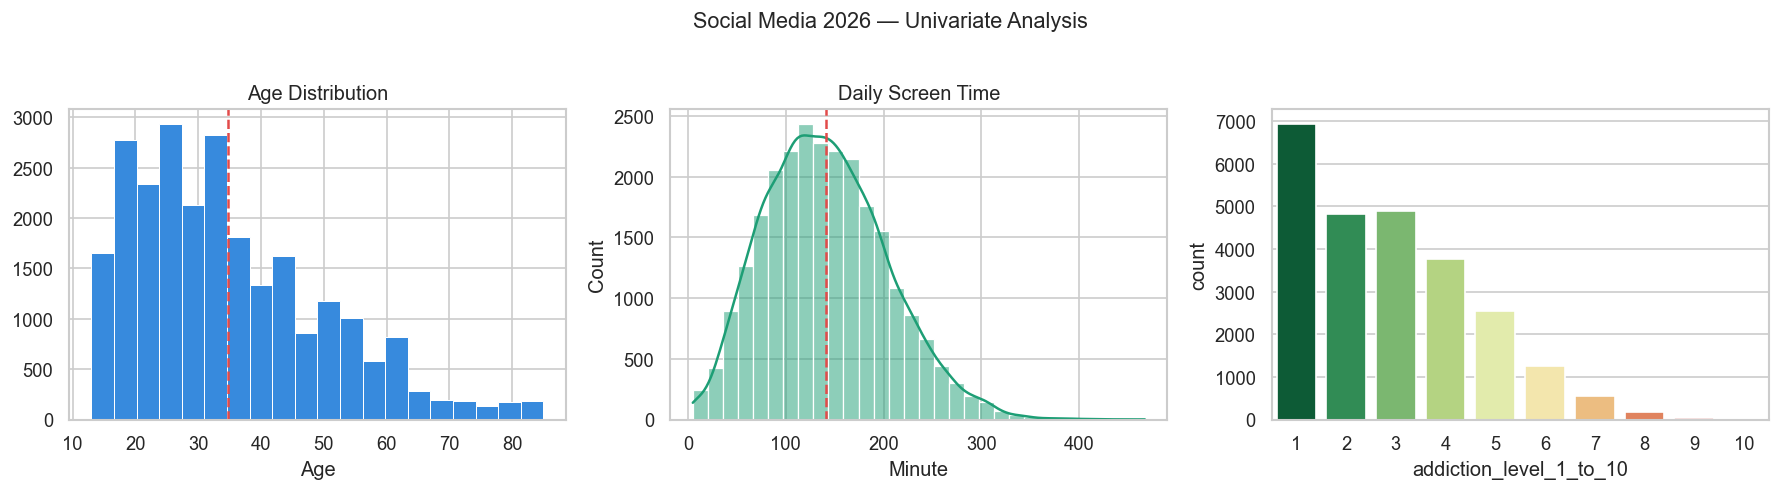

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Age ─────────────────────────────────────
axes[0].hist(df['age'], bins=20, color='#378ADD',
             edgecolor='white', linewidth=0.6)
axes[0].axvline(df['age'].mean(), color='#E24B4A',
               linestyle='--', linewidth=1.5)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# ── Screen Time───────────────────────────
sns.histplot(data=df, x='daily_screen_time_minutes',
             bins=30, kde=True, color='#1D9E75',
             ax=axes[1])
axes[1].axvline(df['daily_screen_time_minutes'].mean(),
               color='#E24B4A', linestyle='--', linewidth=1.5)
axes[1].set_title('Daily Screen Time')
axes[1].set_xlabel('Minute')

# ── Addiction Level ────────────────────────
sns.countplot(data=df, x='addiction_level_1_to_10', 
              hue='addiction_level_1_to_10', 
              palette='RdYlGn_r', 
              legend=False, 
              ax=axes[2])

plt.suptitle('Social Media 2026 — Univariate Analysis',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

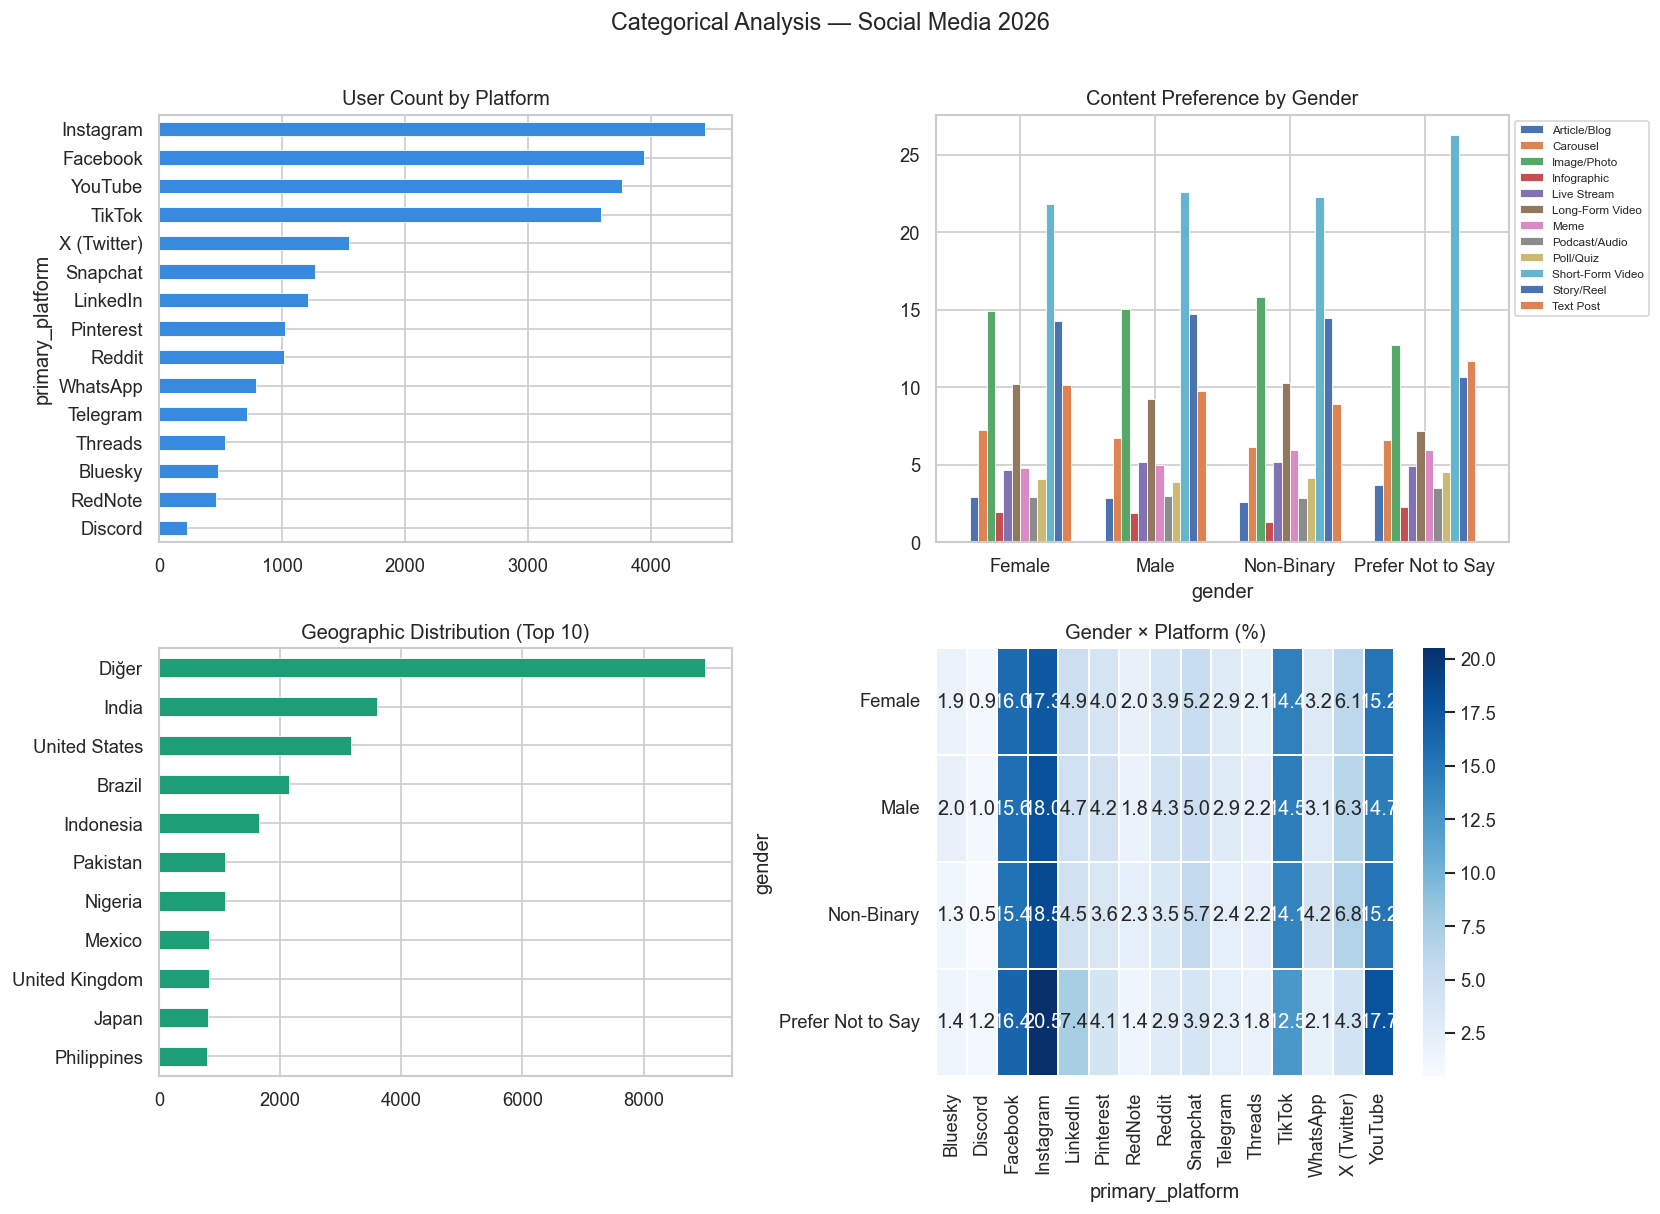

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('social_media_user_behavior.csv')
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Platform Breakdown ──────────────────
pc = df['primary_platform'].value_counts().sort_values()
pc.plot(kind='barh', ax=axes[0,0], color='#378ADD',
        edgecolor='white', linewidth=0.5)
axes[0,0].set_title('User Count by Platform')

# ── Gender × Content Type ────────────
ct = pd.crosstab(df['gender'], df['preferred_content_type'],
                 normalize='index') * 100
ct.plot(kind='bar', ax=axes[0,1], width=0.75,
        edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Content Preference by Gender')
axes[0,1].legend(fontsize=7, bbox_to_anchor=(1,1))
axes[0,1].tick_params(axis='x', rotation=0)

# ── Geographic Distribution (Top 10) ────────────
top10 = df['country'].value_counts().head(10)
other = df['country'].value_counts().iloc[10:].sum()
vc = pd.concat([top10, pd.Series({'Diğer': other})]).sort_values()
vc.plot(kind='barh', ax=axes[1,0], color='#1D9E75',
        edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Geographic Distribution (Top 10)')

# ── Gender × Platform heatmap ────────
hd = pd.crosstab(df['gender'], df['primary_platform'],
                 normalize='index') * 100
sns.heatmap(hd.round(1), annot=True, fmt='.1f',
            cmap='Blues', linewidths=0.9
            , ax=axes[1,1])
axes[1,1].set_title('Gender × Platform (%)')

plt.suptitle('Categorical Analysis — Social Media 2026',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

r = 0.708


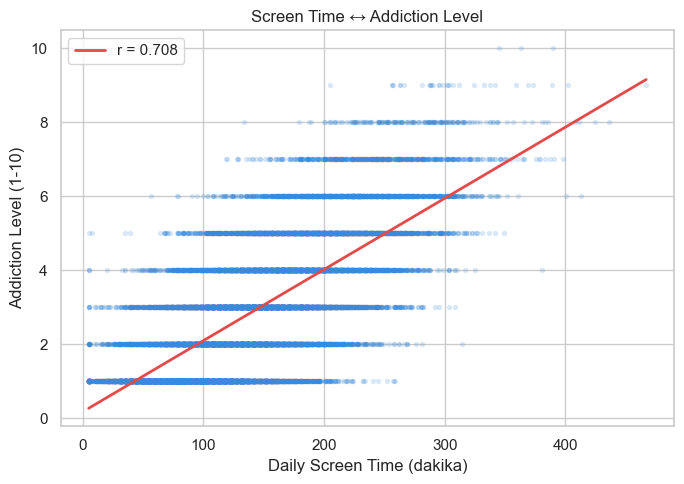

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('social_media_user_behavior.csv')

r = df['daily_screen_time_minutes'].corr(
        df['addiction_level_1_to_10'])
print(f"r = {r:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df['daily_screen_time_minutes'],
    df['addiction_level_1_to_10'],
    alpha=0.15,       # şeffaflık — 25K nokta üst üste gelir
    s=8,             # nokta boyutu küçük tut
    color='#378ADD'
)


import numpy as np
z = np.polyfit(df['daily_screen_time_minutes'],
               df['addiction_level_1_to_10'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['daily_screen_time_minutes'].min(),
                     df['daily_screen_time_minutes'].max(), 100)
ax.plot(x_line, p(x_line), color='#E24B4A',
        linewidth=2, label=f'r = {r:.3f}')

ax.set_xlabel('Daily Screen Time (dakika)')
ax.set_ylabel('Addiction Level (1-10)')
ax.set_title('Screen Time ↔ Addiction Level')
ax.legend()
plt.tight_layout()
plt.show()

r = 0.007
Temiz veri r = -0.008


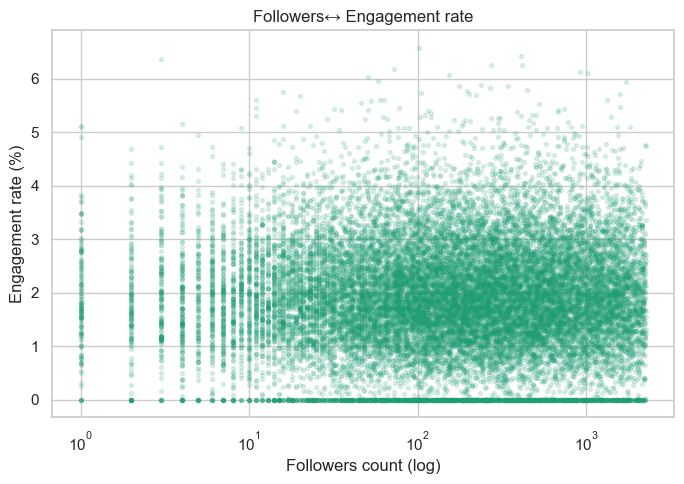

In [17]:
r2 = df['followers_count'].corr(df['engagement_rate_pct'])
print(f"r = {r2:.3f}")

Q1 = df['followers_count'].quantile(0.25)
Q3 = df['followers_count'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['followers_count'] >= Q1 - 1.5*IQR) &
              (df['followers_count'] <= Q3 + 1.5*IQR)]

r2_clean = df_clean['followers_count'].corr(
               df_clean['engagement_rate_pct'])
print(f"Temiz veri r = {r2_clean:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean['followers_count'],
           df_clean['engagement_rate_pct'],
           alpha=0.15, s=8, color='#1D9E75')
ax.set_xscale('log')   # logaritmik eksen — büyük fark varsa
ax.set_xlabel('Followers count (log)')
ax.set_ylabel('Engagement rate (%)')
ax.set_title('Followers↔ Engagement rate')
plt.tight_layout()
plt.show()

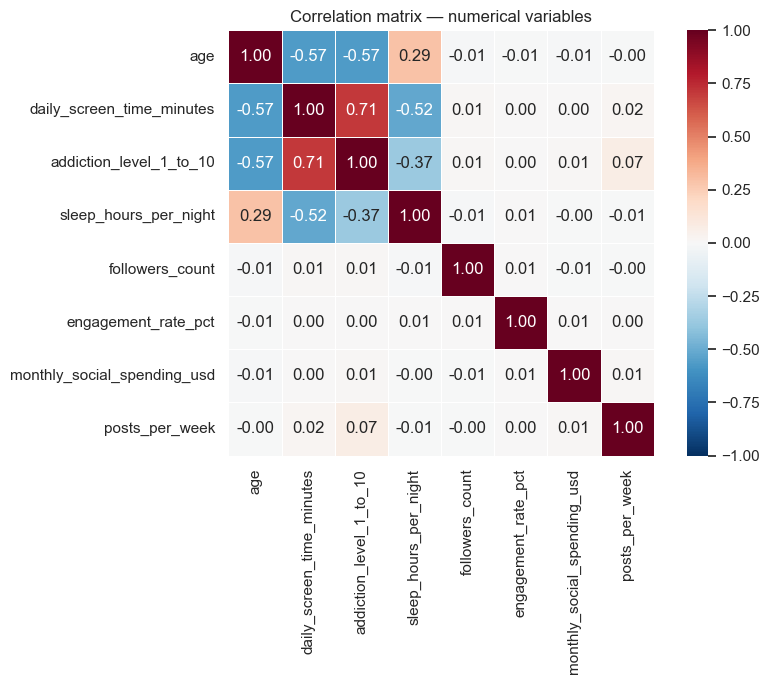

                         var1                       var2         r     abs_r
7   daily_screen_time_minutes    addiction_level_1_to_10  0.708376  0.708376
0                         age  daily_screen_time_minutes -0.567585  0.567585
1                         age    addiction_level_1_to_10 -0.566831  0.566831
8   daily_screen_time_minutes      sleep_hours_per_night -0.521594  0.521594
13    addiction_level_1_to_10      sleep_hours_per_night -0.369818  0.369818


In [18]:
num_cols = [
    'age', 'daily_screen_time_minutes',
    'addiction_level_1_to_10', 'sleep_hours_per_night',
    'followers_count', 'engagement_rate_pct',
    'monthly_social_spending_usd', 'posts_per_week'
]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,           
    fmt='.2f',
    cmap='RdBu_r',        
    center=0,             
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation matrix — numerical variables')
plt.tight_layout()
plt.show()

corr_pairs = (corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index())
corr_pairs.columns = ['var1', 'var2', 'r']
corr_pairs['abs_r'] = corr_pairs['r'].abs()
print(corr_pairs.sort_values('abs_r', ascending=False).head(5))

   platform  monthly_active_users_billions  year_over_year_growth_pct  avg_daily_time_minutes  avg_engagement_rate_pct
   Facebook                           3.07                        2.5                      33                      1.5
  Instagram                           3.00                       13.0                      35                      2.2
   WhatsApp                           3.00                        4.0                      28                      0.0
    YouTube                           2.58                        5.5                      48                      1.9
     TikTok                           1.99                       17.0                      58                      2.8
     WeChat                           1.41                        1.5                      30                      0.0
   Telegram                           1.00                       12.0                      18                      0.0
  Messenger                           0.94      

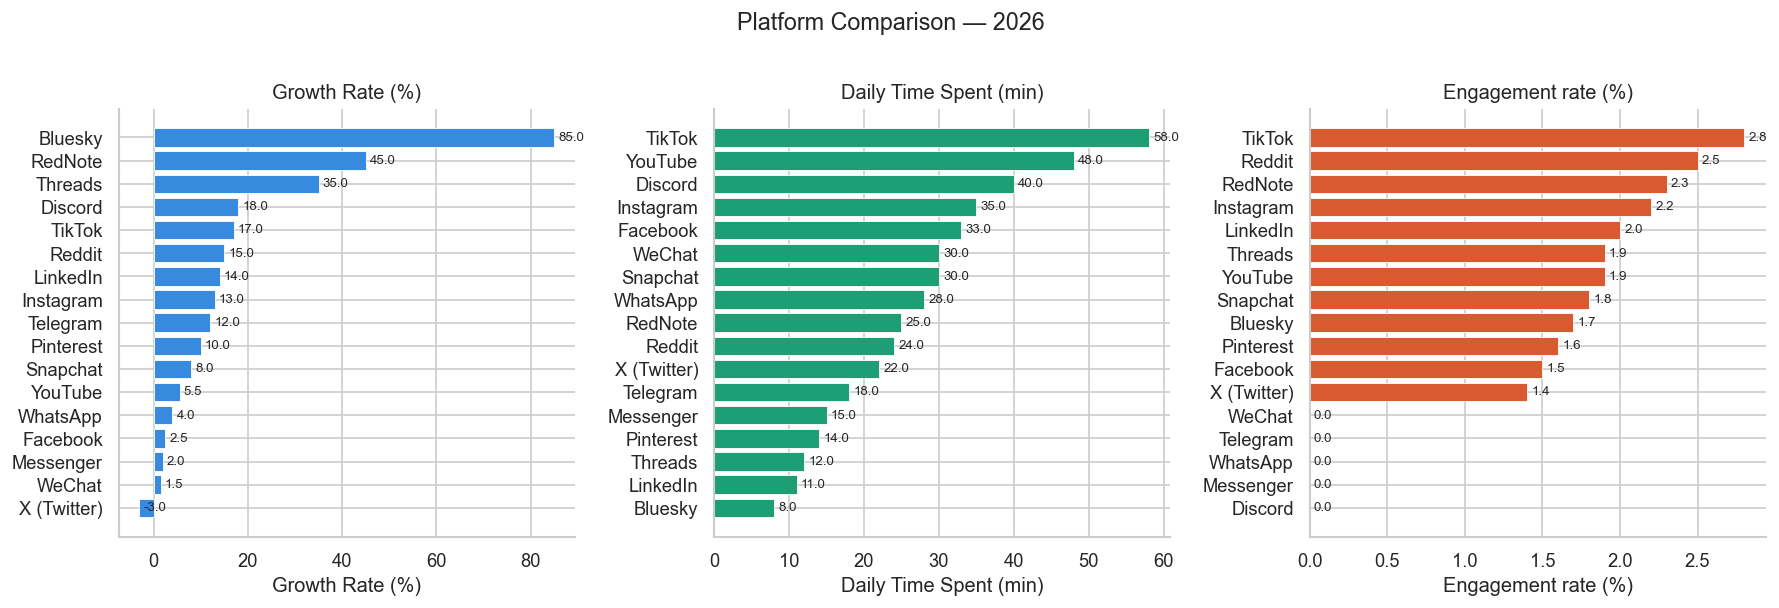

In [65]:
df_p = pd.read_csv('platform_statistics_2026.csv')

print(df_p[['platform', 'monthly_active_users_billions',
            'year_over_year_growth_pct',
            'avg_daily_time_minutes',
            'avg_engagement_rate_pct']]
      .sort_values('monthly_active_users_billions', ascending=False)
      .to_string(index=False))

# ── Growth ──────────────────────
en_hizli = df_p.nlargest(3, 'year_over_year_growth_pct')[
    ['platform', 'year_over_year_growth_pct']]
print("Fastest-growing platform:", en_hizli.to_string(index=False))

# ── Daily Time ──────────────────────
en_uzun = df_p.nlargest(3, 'avg_daily_time_minutes')[
    ['platform', 'avg_daily_time_minutes']]
print("Maximum daily time spent:", en_uzun.to_string(index=False))

# ── Engagement Rate ────────────────────────
en_aktif = df_p.nlargest(3, 'avg_engagement_rate_pct')[
    ['platform', 'avg_engagement_rate_pct']]
print("Highest engagement rate:", en_aktif.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('year_over_year_growth_pct', 'Growth Rate (%)',   '#378ADD'),
    ('avg_daily_time_minutes',    'Daily Time Spent (min)', '#1D9E75'),
    ('avg_engagement_rate_pct',   'Engagement rate (%)', '#D85A30'),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = df_p.sort_values(col, ascending=True)
    ax.barh(data['platform'], data[col],
            color=color, edgecolor='white', linewidth=0.5)
 
    for i, (val, _) in enumerate(zip(data[col], data['platform'])):
        ax.text(val + data[col].max()*0.01, i,
                f'{val:.1f}', va='center', fontsize=8)
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Platform Comparison — 2026', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('platform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
import pandas as pd
df_users=pd.read_csv('social_media_user_behavior.csv')
df_platform=pd.read_csv('platform_statistics_2026.csv')
df_merged = pd.merge(
    df_users,                         
    df_platform,                     
    left_on='primary_platform',      
    right_on='platform',            
    how='left'
)

print(f"Boyut: {df_merged.shape}")  
print(df_merged.columns.tolist())

Boyut: (25000, 56)
['user_id', 'age', 'age_group', 'gender', 'country', 'occupation', 'education_level', 'income_bracket', 'relationship_status', 'primary_platform', 'num_platforms_used', 'daily_screen_time_minutes', 'weekly_sessions', 'avg_session_duration_minutes', 'preferred_content_type', 'primary_device', 'usage_purpose', 'posts_per_week', 'likes_per_day', 'comments_per_day', 'shares_per_week', 'followers_count', 'following_count', 'engagement_rate_pct', 'video_consumption_daily_minutes', 'has_purchased_via_social', 'follows_influencers', 'ad_click_frequency', 'monthly_social_spending_usd', 'uses_privacy_settings', 'experienced_cyberbullying', 'reports_fake_news_frequency', 'self_reported_mental_health_effect', 'sleep_hours_per_night', 'addiction_level_1_to_10', 'productivity_impact', 'platform_satisfaction', 'account_created_date', 'account_age_years', 'is_verified_account', 'is_content_creator', 'uses_ai_features', 'daily_notifications', 'checks_phone_first_morning', 'uses_scree

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')

df_users    = pd.read_csv('social_media_user_behavior.csv')
df_platform = pd.read_csv('platform_statistics_2026.csv')

df_users['primary_platform'] = (df_users['primary_platform']
    .str.strip().str.title()
    .replace({'Tiktok':'TikTok','Youtube':'YouTube',
              'Whatsapp':'WhatsApp','Linkedin':'LinkedIn'}))

df = pd.merge(df_users, df_platform,
              left_on='primary_platform',
              right_on='platform', how='left')
df = df.drop(columns=['platform'], errors='ignore')

seg1 = df.groupby('primary_platform').agg(
    ort_bagimlilik=('addiction_level_1_to_10','mean'),
    ort_ekran=('daily_screen_time_minutes','mean'),
    n=('user_id','count')).round(2)
print(seg1.sort_values('ort_bagimlilik', ascending=False))

age_pt = pd.crosstab(df['age_group'], df['primary_platform'],
                     normalize='index') * 100
print("Her yaş grubunun 1. platformu:")
print(age_pt.idxmax(axis=1))

df['is_negative'] = (
    df['self_reported_mental_health_effect']=='Mostly Negative'
).astype(int)
mental = df.groupby('primary_platform')['is_negative'].mean()*100
print("Platform bazında negatif ruh sağlığı etkisi (%):")
print(mental.sort_values(ascending=False).round(1))

                  ort_bagimlilik  ort_ekran     n
primary_platform                                 
Discord                     3.00     146.51   230
Reddit                      2.97     141.79  1016
LinkedIn                    2.96     140.33  1209
Pinterest                   2.95     141.97  1021
TikTok                      2.94     142.57  3594
Snapchat                    2.90     141.25  1267
Telegram                    2.89     142.33   718
YouTube                     2.88     141.17  3759
Facebook                    2.87     140.22  3939
Instagram                   2.86     140.06  4434
WhatsApp                    2.86     143.40   791
X (Twitter)                 2.86     140.67  1544
Bluesky                     2.81     142.49   478
Rednote                     2.78     141.21   466
Threads                     2.78     137.75   534
Her yaş grubunun 1. platformu:
age_group
13-17    Instagram
18-24    Instagram
25-34    Instagram
35-44    Instagram
45-54    Instagram
55-64    Insta

In [9]:
import pandas as pd
import os

os.makedirs('output', exist_ok=True)

df_users    = pd.read_csv('social_media_user_behavior.csv')
df_platform = pd.read_csv('platform_statistics_2026.csv')

df_users['primary_platform'] = (
    df_users['primary_platform'].str.strip().str.title()
    .replace({'Tiktok':'TikTok','Youtube':'YouTube',
              'Whatsapp':'WhatsApp','Linkedin':'LinkedIn'})
)

df_merged = pd.merge(
    df_users, df_platform,
    left_on='primary_platform', right_on='platform',
    how='left'
).drop(columns=['platform'], errors='ignore')

df_merged['is_negative'] = (
    df_merged['self_reported_mental_health_effect']
    == 'Mostly Negative'
).astype(int)

df_merged.to_csv('output/dashboard_users.csv', index=False)
print(f"✓ dashboard_users.csv — {df_merged.shape[0]} satır")

summary = df_merged.groupby('primary_platform').agg(
    kullanici_sayisi     = ('user_id',                   'count'),
    ort_ekran_dk         = ('daily_screen_time_minutes',  'mean'),
    ort_bagimlilik       = ('addiction_level_1_to_10',    'mean'),
    negatif_saglik_pct   = ('is_negative',                'mean'),
    sosyal_alisveris_pct = ('has_purchased_via_social',    'mean'),
    ort_harcama_usd      = ('monthly_social_spending_usd', 'mean')
).round(2).reset_index()
summary[['negatif_saglik_pct','sosyal_alisveris_pct']] *= 100
summary.to_csv('output/dashboard_platform_summary.csv', index=False)
print(f"✓ dashboard_platform_summary.csv — {len(summary)} satır")

✓ dashboard_users.csv — 25000 satır
✓ dashboard_platform_summary.csv — 15 satır


In [4]:
import pandas as pd
df_users    = pd.read_csv('social_media_user_behavior.csv')
platform_counts = df_users['primary_platform'].value_counts()
platform_pct = (platform_counts / len(df_users) * 100).round(1)
print(platform_pct)

primary_platform
Instagram      17.7
Facebook       15.8
YouTube        15.0
TikTok         14.4
X (Twitter)     6.2
Snapchat        5.1
LinkedIn        4.8
Pinterest       4.1
Reddit          4.1
WhatsApp        3.2
Telegram        2.9
Threads         2.1
Bluesky         1.9
RedNote         1.9
Discord         0.9
Name: count, dtype: float64


In [7]:
import pandas as pd
df_platform = pd.read_csv('platform_statistics_2026.csv')
print(df_platform[['platform', 'social_commerce_adoption_pct']]
      .sort_values('social_commerce_adoption_pct', ascending=False)
      .to_string(index=False))

   platform  social_commerce_adoption_pct
   Facebook                          60.9
     WeChat                          45.0
     TikTok                          43.8
    RedNote                          40.0
  Instagram                          35.0
  Pinterest                          25.0
    YouTube                          22.0
   WhatsApp                          15.0
  Messenger                          10.0
   LinkedIn                           8.0
   Snapchat                           8.0
X (Twitter)                           5.0
   Telegram                           5.0
     Reddit                           3.0
    Threads                           3.0
    Discord                           2.0
    Bluesky                           1.0
